<a href="https://colab.research.google.com/github/Dharshini13002/Deep-learning-codes-of-FER/blob/main/FER2013CNN%2BTRANSFORMER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

In [2]:
# Kaggle API setup
os.environ["KAGGLE_USERNAME"] = "dharshini1333333"  # Replace with your Kaggle username
os.environ["KAGGLE_KEY"] = "cecd150b72b85d04cc229a681a646b88"  # Replace with your Kaggle API key

In [3]:
from kaggle.api.kaggle_api_extended import KaggleApi

In [4]:
# Enable CuDNN benchmarking for performance
cudnn.benchmark = True
plt.ion()  # Enable interactive mode for matplotlib

In [5]:
# Use the existing Fer2013 dataset if present
data_dir = '/content/fer2013.csv'
if os.path.exists(data_dir):
    print("FER2013 dataset already exists at:", data_dir)
else:
    print("FER2013 dataset not found at:", data_dir)
    print("Downloading the dataset using Kaggle API...")
    api = KaggleApi()
    api.authenticate()
    api.dataset_download_files('deadskull7/fer2013', path='/content/', unzip=True)
    print("Dataset downloaded and unzipped successfully.")

FER2013 dataset not found at: /content/fer2013.csv
Dataset URL: https://www.kaggle.com/datasets/deadskull7/fer2013
Dataset downloaded and unzipped successfully.


In [6]:
# Data transformations for training and validation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

# Load the fer2013 dataset
df = pd.read_csv(data_dir)

# Split the data into training, validation, and test sets
# We'll use the 'Usage' column to split the data
train_df = df[df['Usage'] == 'Training']
val_df = df[df['Usage'] == 'PublicTest']
test_df = df[df['Usage'] == 'PrivateTest']

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

# Define a custom dataset class
class Fer2013Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.labels = dataframe['emotion'].values
        self.pixels = dataframe['pixels'].apply(lambda x: np.array(x.split(), dtype='uint8').reshape(48, 48)).values

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        label = self.labels[idx]
        image = self.pixels[idx]
        image = Image.fromarray(image).convert('RGB') # Convert to PIL Image and RGB

        if self.transform:
            image = self.transform(image)

        return image, label

# Update data_transforms to include a conversion to PIL Image and RGB
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
     'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}


# Create custom datasets
image_datasets = {
    'train': Fer2013Dataset(train_df, transform=data_transforms['train']),
    'val': Fer2013Dataset(val_df, transform=data_transforms['val']),
    'test': Fer2013Dataset(test_df, transform=data_transforms['test'])
}

# Create dataloaders
dataloaders = {
    x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                   shuffle=True, num_workers=2 if torch.cuda.is_available() else 0) # Use 2 workers if CUDA is available, otherwise 0
    for x in ['train', 'val', 'test']
}

dataset_sizes = {
    x: len(image_datasets[x]) for x in ['train', 'val', 'test']
}

# Define the class names (emotions)
class_names = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print("Datasets and DataLoaders created successfully!")

Training samples: 28709
Validation samples: 3589
Test samples: 3589
Datasets and DataLoaders created successfully!


In [8]:
# Helper to show images
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

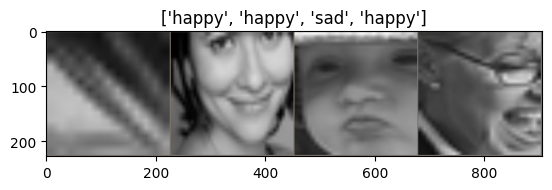

In [9]:
# Show a batch of training data
inputs, classes = next(iter(dataloaders['train']))
out = torchvision.utils.make_grid(inputs)
imshow(out, title=[class_names[x] for x in classes])

In [10]:
# Training function
def train_model(model, criterion, optimizer, scheduler, num_epochs=5):
    since = time.time()

    # Initialize lists to store losses and accuracies
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    with TemporaryDirectory() as tempdir:
        best_model_path = os.path.join(tempdir, 'best_model.pt')
        torch.save(model.state_dict(), best_model_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                model.train() if phase == 'train' else model.eval()

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)

                # Step the scheduler if in training phase
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # Store epoch loss and accuracy
                if phase == 'train':
                    train_losses.append(epoch_loss)
                    train_accs.append(epoch_acc.item()) # Convert to item() for list
                else: # phase == 'val'
                    val_losses.append(epoch_loss)
                    val_accs.append(epoch_acc.item()) # Convert to item() for list

                # deep copy the model if it's the best validation accuracy
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:.4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_path))

    # Return the loss and accuracy history
    return model, train_losses, val_losses, train_accs, val_accs

In [11]:
# Visualization of model predictions
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for inputs, labels in dataloaders['val']:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images // 2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'Predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

In [12]:
# Predict a single image
def visualize_model_predictions(model, img_path):
    model.eval()
    img = Image.open(img_path)
    img = data_transforms['val'](img)
    img = img.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img)
        _, preds = torch.max(outputs, 1)
        plt.figure()
        plt.title(f'Predicted: {class_names[preds[0]]}')
        imshow(img.cpu().data[0])


In [13]:
%env CUDA_LAUNCH_BLOCKING=1


env: CUDA_LAUNCH_BLOCKING=1


In [14]:
import pandas as pd

df = pd.read_csv("fer2013.csv")
print("Unique labels:", df["emotion"].unique())
print("Label range:", df["emotion"].min(), "to", df["emotion"].max())


Unique labels: [0 2 4 6 3 5 1]
Label range: 0 to 6


In [16]:
# Load pretrained ResNet18
model_conv = models.resnet18(weights='IMAGENET1K_V1')


In [17]:
# Replace final fully connected layer for FER2013 emotions
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 7)   # use 8 if your labels check showed 0–7

In [18]:
# Move model to device
model_conv = model_conv.to(device)

In [19]:
# Loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_conv.parameters(), lr=0.001, momentum=0.9)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.1)

In [20]:
# Train the model and capture the history
best_model, train_losses, val_losses, train_accs, val_accs = train_model(model_conv, criterion, optimizer, scheduler, num_epochs=7)

Epoch 0/6
----------
train Loss: 1.6893 Acc: 0.3535
val Loss: 1.5204 Acc: 0.4845

Epoch 1/6
----------
train Loss: 1.4419 Acc: 0.4500
val Loss: 1.1557 Acc: 0.5695

Epoch 2/6
----------
train Loss: 1.3511 Acc: 0.4835
val Loss: 1.1525 Acc: 0.5854

Epoch 3/6
----------
train Loss: 1.2909 Acc: 0.5059
val Loss: 1.0557 Acc: 0.5935

Epoch 4/6
----------
train Loss: 1.2550 Acc: 0.5226
val Loss: 1.1103 Acc: 0.6013

Epoch 5/6
----------
train Loss: 1.2184 Acc: 0.5342
val Loss: 1.0647 Acc: 0.6102

Epoch 6/6
----------
train Loss: 1.1954 Acc: 0.5425
val Loss: 1.0446 Acc: 0.6205

Training complete in 28m 58s
Best val Acc: 0.6205


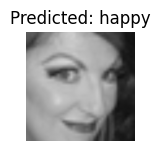

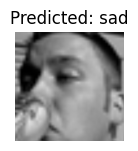

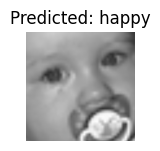

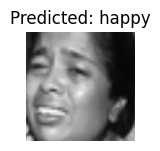

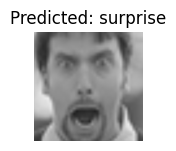

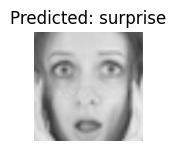

In [21]:
# Visualize model performance
visualize_model(model_conv)

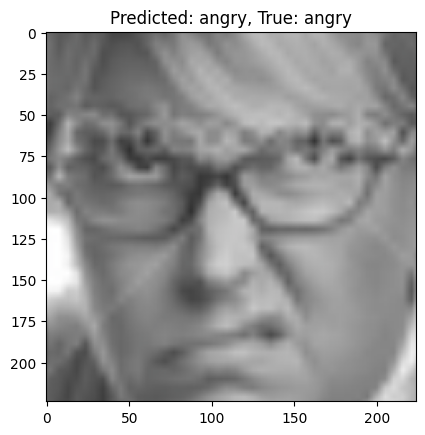

In [23]:
# Get a sample image from the test set dataframe
sample_test_image, sample_test_label = image_datasets['test'][0]

# The visualize_model_predictions function expects an image path,
# so we need to modify it or create a new function to handle image tensors directly.
# For now, let's modify the function to accept an image tensor.

# Redefine the visualize_model_predictions function to accept an image tensor and its true label
def visualize_model_predictions(model, image_tensor, true_label):
    model.eval()
    img = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img)
        _, preds = torch.max(outputs, 1)
        plt.figure()
        plt.title(f'Predicted: {class_names[preds[0]]}, True: {class_names[true_label]}')
        imshow(img.cpu().data[0])

# Use the modified function with the sample test image
visualize_model_predictions(model_conv, sample_test_image, sample_test_label)

In [24]:
plt.ioff()
plt.show()

In [25]:
# =============================
# Function to check accuracy
# =============================

def check_accuracy(model, loader, device):
    model.eval()   # evaluation mode
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    acc = 100 * correct / total
    return acc

# =============================
# Example usage
# =============================
train_acc = check_accuracy(model_conv, dataloaders['train'], device)
test_acc  = check_accuracy(model_conv, dataloaders['test'], device)

print(f"Train Accuracy: {train_acc:.2f}%")
print(f"Test Accuracy : {test_acc:.2f}%")

Train Accuracy: 57.00%
Test Accuracy : 62.89%
